# IberFire: característiques que envolten els incendis a la Península Ibèrica
### Visualització de dades


#### Esther Ruano Hortoneda
#### Gener 2026

Exploració del dataset [IberFire](https://ekoizpen-zientifikoa.ehu.eus/documentos/6813ec1ee6f3433a41370134?utm_source=chatgpt.com) d'acord amb les qüestions plantejades a la [primera part de la pràctica](https://github.com/EstherRH00/IberFire/blob/main/EstherRuanoHortoneda-Part1.pdf).

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import dask

ds = xr.open_dataset("IberFire.nc", chunks="auto")

## Diccionari de variables
* `x_index, y_index`: dimensió; valors enters dels intervals [0, 1187], [0,919] respectivament, que representen les coordenades x i y.
* `is_spain`: dimensió; booleà que representa si és Espanya o no.
* `is_fire, is_near_fire`: fet; booleans per indicar si hi ha foc dins la cel·la o es troba a prop de foc.
* `x_coordinate, y_coordinate`: dimensió; valors reals, corresponents a les coordenades EPSG:3035.
* `is_sea, is_waterbody`: dimensió; booleans que indiquen si el quilòmetre quadrat és aigua i/o mar.
* `AutonomousCommunities`: dimensió; enter [0,19] que indica la comunitat autònoma.
* `CLC_2006/2012/2018_<...>`: dimensió; proporcions entre 0 i 1 que indiquen el percentatge del quilòmetre quadrat que ocupa cada una de les explotacions dins de cada una de les tres etiquetes del projecte [CORINE Land Cover](https://land.copernicus.eu/en/products/corine-land-cover) als anys 2006, 2012 i 2018.
* `aspect_1…8,NODATA`: dimensió; proporcions entre 0 i 1 que indiquen la proporció del terreny que té cada inclinació.
* `elevation<…>, slope<...>, roughness<...>`: dimensió; valors relacionats amb el desnivell i inclinació del terreny.
* `dist_to<...>`: dimensió; mitjanes i desviacions de les distàncies a carreteres, rius i vies de tren en cada un dels quadrats de la graella.
* `is_natura2000`: dimensió; booleà que indica si forma part de la xarxa [Natura 2000](https://www.miteco.gob.es/es/biodiversidad/temas/espacios-protegidos/red-natura-2000.html).
* `popdens_20<....>`: dimensió; densitat depoblació en persones per quilòmetre quadrat per cada un dels anys entre 2008 i 2020.
* `is_holiday`: booleà que indica si és festiu o no.
* `t2m/RH/surface_pressure/total_precipitation/wind_speed/wind_direction_<....>`: dimensió; valors relatius al temps que ha fet en cada posició en cada dia concret: temperatura, humitat, pressió, precipitacions, direcció i velocitat del vent. Inclou mitjanes, rangs, mínims i màxims.
* `FAPAR`: dimensió; Fracció de Radiació Activa Absorvida Fotosintèticament
* `LAI, NDVI`: dimensió; índex de vegetació i fullatge per metre quadrat.
* `LST`: dimensió; Temperatura a la Superfície de la Terra, en graus Kelvin.
* `SWI_001/005/010/020`: dimensió; percentatge d’aigua al sol a 1, 5, 10 i 20 centímetres sota terra, respectivament.
* `FWI`: fet derivat; Fire Weather Index, columna afegida a la segona versió del dataset per ser utilitzada com a baseline model.


## 1. On i quan s’han produït incendis a Espanya entre 2007 i 2024? 
Primerament veurem on s’han produit incendis al llarg del temps, utilitzant la variable is_fire. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.colors import ListedColormap, BoundaryNorm
import ipywidgets as widgets
from datetime import datetime

cmap = ListedColormap([
    "#2c7bb6",  # Sea
    "#d9d9d9",  # Land
    "#66bd63",  # Spain
    "#d7191c",  # Fire
])

norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

legend_labels = ["Sea", "Land", "Spain", "Fire"]
legend_handles = [
    plt.Line2D([0], [0], marker="s", linestyle="",
               markerfacecolor=cmap(i), markersize=10)
    for i in range(4)
]

out = widgets.Output()

def plot_fire_at_date(date):
    with out:
        out.clear_output(wait=True)

        ds_t = ds.sel(time=np.datetime64(date))

        category = xr.zeros_like(ds_t["is_spain"], dtype=np.uint8)

        category = xr.where(ds_t["is_sea"] == 1, 0, category)
        category = xr.where(
            (ds_t["is_sea"] == 0) & (ds_t["is_spain"] == 0),
            1,
            category,
        )
        category = xr.where(
            (ds_t["is_spain"] == 1) & (ds_t["is_fire"] == 0),
            2,
            category,
        )
        category = xr.where(ds_t["is_fire"] == 1, 3, category)

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(category, cmap=cmap, norm=norm)
        ax.set_title(f"Fire occurrence – {date}")
        ax.axis("off")

        ax.legend(
            legend_handles,
            legend_labels,
            loc="lower left",
            frameon=True
        )

        plt.show()


In [3]:
dates = ds.time.values.astype("datetime64[D]").astype(str)

slider = widgets.SelectionSlider(
    options=dates,
    value=dates[0],
    description="Date",
    layout=widgets.Layout(width="800px"),
    continuous_update=False
)

datepicker = widgets.DatePicker(
    description="Select date",
    value=datetime.strptime(dates[0], "%Y-%m-%d")
)


In [4]:
def on_slider_change(change):
    datepicker.value = datetime.strptime(change["new"], "%Y-%m-%d")
    plot_fire_at_date(change["new"])

def on_datepicker_change(change):
    date_str = change["new"].strftime("%Y-%m-%d")
    slider.value = date_str

slider.observe(on_slider_change, names="value")
datepicker.observe(on_datepicker_change, names="value")


In [5]:
plot_fire_at_date(dates[0])

widgets.VBox([
    slider,
    datepicker,
    out
])

## 2. Quines condicions meteorològiques i de vegetació precedeixen un incendi? 
Per respondre-la, entendrem quines característiques hi havia al terreny els cinc dies abans de l'incendi: 
* LAI
* NDV
* LSDT
* SWI_001/005/010/020
* t2m/RH/surface_pressure/total_precipitation/wind_speed/ wind_direction_<....>. 

Per entendre-ho millor, permetrem filtrar per tipus de terreny segons CORINE Land Cover i Natura 2000. Així veurem si hi ha algun patró al sol que ens pot indicar risc d’incendi.

Dels anys que inclou el dataset, 2022 va ser el que presenta més incendis. Per reduir el volum de dades, d'ara en endavant, ens centrarem en aquest ([font](https://elpais.com/clima-y-medio-ambiente/2025-08-18/los-datos-apuntan-ya-al-peor-ano-de-incendios-en-espana-en-tres-decadas-tras-un-agosto-brutal.html)).

![Superficie cremada per anys](./img/grafica2022.png)

### Primerament estudiem segons si forma part, o no de la [Xarxa Natura 2000](https://www.miteco.gob.es/es/biodiversidad/temas/espacios-protegidos/red-natura-2000.html)

In [6]:
import xarray as xr
import numpy as np
import pandas as pd

ds_2022 = ds.sel(time=slice("2021-12-27", "2022-12-31"))
days_before = [1, 2, 3, 4, 5]

fire = ds_2022["is_fire"]
fire_start = (fire == 1) & (fire.shift(time=1) == 0)

vars_to_analyze = [
    "LAI", "NDVI", "LST",
    "SWI_001", "SWI_005", "SWI_010", "SWI_020",
    "t2m_mean", "RH_mean", "surface_pressure_mean",
    "total_precipitation_mean", "wind_speed_mean", "wind_direction_mean"
]

# ============================================================
# STEP 1: Load fire_start mask and natura2000 to memory
# ============================================================
fire_start_vals = fire_start.values  # shape: (time, y, x)

# Load natura2000 (static - no time dimension)
natura2000_vals = ds_2022["is_natura2000"].values  # shape: (y, x)

# ============================================================
# STEP 2: Precompute ALL shifted masks ONCE
# ============================================================
fire_start_shifted = {}
for d in days_before:
    shifted = np.roll(fire_start_vals, d, axis=0)
    shifted[:d, :, :] = False
    fire_start_shifted[d] = shifted

# ============================================================
# STEP 3: Load ALL variables to memory ONCE
# ============================================================
data_vars = {}
for var in vars_to_analyze:
    data_vars[var] = ds_2022[var].values

# Results structure: results[var][d][natura_status] = list of values
results = {}

for var in vars_to_analyze:
    var_data = data_vars[var]
    results[var] = {}
   
    for d in days_before:
        mask = fire_start_shifted[d]
       
        results[var][d] = {
            0: [],  # Outside Natura2000
            1: [],  # Inside Natura2000
        }
       
        # Get indices where fire started
        time_idx, y_idx, x_idx = np.where(mask)
       
        for t, y, x in zip(time_idx, y_idx, x_idx):
            value = var_data[t, y, x]
            natura_status = natura2000_vals[y, x]
           
            if not np.isnan(value) and not np.isnan(natura_status):
                natura_key = int(natura_status)
                results[var][d][natura_key].append(value)
   
    total_n0 = sum(len(results[var][d][0]) for d in days_before)
    total_n1 = sum(len(results[var][d][1]) for d in days_before)

In [7]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import math

# Day colors
day_colors = {
    5: "#6A5ACD",
    4: "#9370DB",
    3: "#FF69B4",
    2: "#FF8C69",
    1: "#E63946",
}

def plot_violins(include_natura0, include_natura1):
    """Plot violin plots based on selected Natura2000 filters."""
   
    n_vars = len(vars_to_analyze)
    n_cols = 2
    n_rows = math.ceil(n_vars / n_cols)
   
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        squeeze=False
    )
   
    for i, var in enumerate(vars_to_analyze):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]
       
        # Combine data based on checkbox selections
        data = []
        for d in days_before:
            combined = []
            if include_natura0:
                combined.extend(results[var][d][0])
            if include_natura1:
                combined.extend(results[var][d][1])
            data.append(combined if combined else [np.nan])  # Avoid empty lists
       
        # Check if we have any data
        if all(len(d) == 1 and np.isnan(d[0]) for d in data):
            ax.text(0.5, 0.5, "No data selected", ha="center", va="center",
                    transform=ax.transAxes, fontsize=12, color="gray")
            ax.set_title(var, fontsize=11, pad=6)
            continue
       
        parts = ax.violinplot(
            data,
            showmeans=False,
            showmedians=True,
            showextrema=False
        )
       
        for body, d in zip(parts["bodies"], days_before):
            body.set_facecolor(day_colors[d])
            body.set_edgecolor("black")
            body.set_alpha(0.75)
            body.set_linewidth(0.8)
       
        parts["cmedians"].set_color("black")
        parts["cmedians"].set_linewidth(1.3)
       
        ax.set_title(var, fontsize=11, pad=6)
        ax.set_xticks(range(1, len(days_before) + 1))
        ax.set_xticklabels([f"{d}d" for d in days_before])
        ax.grid(axis="y", alpha=0.25, linestyle="--")
        ax.set_axisbelow(True)
   
    # Remove empty subplots
    for j in range(i + 1, n_rows * n_cols):
        fig.delaxes(axes[j // n_cols, j % n_cols])
   
    # Add subtitle showing current filter
    filter_text = []
    if include_natura0:
        filter_text.append("Outside Natura2000")
    if include_natura1:
        filter_text.append("Inside Natura2000")
    filter_str = " + ".join(filter_text) if filter_text else "No selection"
   
    fig.suptitle(f"Pre-Fire Conditions by Days Before Ignition\nFilter: {filter_str}",
                 fontsize=14, fontweight="bold", y=1.02)
   
    plt.tight_layout()
    plt.show()

# Create checkboxes
checkbox_natura0 = widgets.Checkbox(
    value=True,
    description='Outside Natura2000 (0)',
    style={'description_width': 'initial'}
)

checkbox_natura1 = widgets.Checkbox(
    value=True,
    description='Inside Natura2000 (1)',
    style={'description_width': 'initial'}
)

# Create output widget
output = widgets.Output()

def update_plot(change):
    """Callback when checkbox changes."""
    with output:
        clear_output(wait=True)
        plot_violins(checkbox_natura0.value, checkbox_natura1.value)

# Connect callbacks
checkbox_natura0.observe(update_plot, names='value')
checkbox_natura1.observe(update_plot, names='value')

# Layout
checkbox_box = widgets.HBox([checkbox_natura0, checkbox_natura1])
ui = widgets.VBox([
    widgets.HTML("<h3>Pre-Fire Conditions Analysis</h3>"),
    widgets.HTML("<p>Select which areas to include:</p>"),
    checkbox_box,
    output
])

# Initial plot
with output:
    plot_violins(True, True)

# Display
display(ui)

### Seguidament, segons el projecte [Corine Land Cover](https://land.copernicus.eu/en/products/corine-land-cover)

Prenem, per cada quilòmetre quadrat, l'etiqueta amb major valor percentual

In [8]:

import numpy as np
import pandas as pd

# ============================================================
# CLC LEVEL DEFINITIONS
# ============================================================

# Level 1: 5 broad categories
clc_level1 = {
    "artificial_proportion": "Artificial surfaces",
    "agricultural_proportion": "Agricultural areas",
    "forest_and_semi_natural_proportion": "Forest and semi-natural areas",
    "wetlands_proportion": "Wetlands",
    "waterbody_proportion": "Water bodies",
}

clc_level1_colors = {
    "artificial_proportion": "#E41A1C",
    "agricultural_proportion": "#FFFF33",
    "forest_and_semi_natural_proportion": "#4DAF4A",
    "wetlands_proportion": "#377EB8",
    "waterbody_proportion": "#00CED1",
}

# Level 2: 14 categories
clc_level2 = {
    "urban_fabric_proportion": "Urban fabric",
    "industrial_proportion": "Industrial, commercial and transport",
    "mine_proportion": "Mine, dump and construction sites",
    "artificial_vegetation_proportion": "Artificial vegetated areas",
    "arable_land_proportion": "Arable land",
    "permanent_crops_proportion": "Permanent crops",
    "pastures_proportion": "Pastures",
    "heterogeneous_agriculture_proportion": "Heterogeneous agricultural areas",
    "forest_proportion": "Forests",
    "scrub_proportion": "Scrub and herbaceous vegetation",
    "open_space_proportion": "Open spaces with little vegetation",
    "inland_wetlands_proportion": "Inland wetlands",
    "maritime_wetlands_proportion": "Maritime wetlands",
    "inland_waters_proportion": "Inland waters",
    "marine_waters_proportion": "Marine waters",
}

clc_level2_colors = {
    "urban_fabric_proportion": "#E41A1C",
    "industrial_proportion": "#B22222",
    "mine_proportion": "#8B0000",
    "artificial_vegetation_proportion": "#FF6347",
    "arable_land_proportion": "#FFFF33",
    "permanent_crops_proportion": "#FFD700",
    "pastures_proportion": "#F0E68C",
    "heterogeneous_agriculture_proportion": "#BDB76B",
    "forest_proportion": "#228B22",
    "scrub_proportion": "#4DAF4A",
    "open_space_proportion": "#90EE90",
    "inland_wetlands_proportion": "#377EB8",
    "maritime_wetlands_proportion": "#4169E1",
    "inland_waters_proportion": "#00CED1",
    "marine_waters_proportion": "#1E90FF",
}

# Level 3: 44 detailed classes
clc_level3 = {
    1: "Continuous urban fabric",
    2: "Discontinuous urban fabric",
    3: "Industrial or commercial units",
    4: "Road and rail networks",
    5: "Port areas",
    6: "Airports",
    7: "Mineral extraction sites",
    8: "Dump sites",
    9: "Construction sites",
    10: "Green urban areas",
    11: "Sport and leisure facilities",
    12: "Non-irrigated arable land",
    13: "Permanently irrigated land",
    14: "Rice fields",
    15: "Vineyards",
    16: "Fruit trees and berry plantations",
    17: "Olive groves",
    18: "Pastures",
    19: "Permanent crops",
    20: "Complex cultivation patterns",
    21: "Land principally occupied by agriculture",
    22: "Agro-forestry areas",
    23: "Broad-leaved forest",
    24: "Coniferous forest",
    25: "Mixed forest",
    26: "Natural grasslands",
    27: "Moors and heathland",
    28: "Sclerophyllous vegetation",
    29: "Transitional woodland-shrub",
    30: "Beaches, dunes, sands",
    31: "Bare rocks",
    32: "Sparsely vegetated areas",
    33: "Burnt areas",
    34: "Glaciers and perpetual snow",
    35: "Inland marshes",
    36: "Peat bogs",
    37: "Salt marshes",
    38: "Salines",
    39: "Intertidal flats",
    40: "Water courses",
    41: "Water bodies",
    42: "Coastal lagoons",
    43: "Estuaries",
    44: "Sea and ocean",
}

# Color gradient for Level 3 (grouped by parent category)
import matplotlib.cm as cm

clc_level3_colors = {}
# Artificial (1-11): Reds
for i in range(1, 12):
    clc_level3_colors[i] = cm.Reds(0.3 + 0.6 * (i - 1) / 10)
# Agricultural (12-22): Yellows/Oranges
for i in range(12, 23):
    clc_level3_colors[i] = cm.YlOrBr(0.3 + 0.6 * (i - 12) / 10)
# Forest & Semi-natural (23-34): Greens
for i in range(23, 35):
    clc_level3_colors[i] = cm.Greens(0.3 + 0.6 * (i - 23) / 11)
# Wetlands (35-39): Blues
for i in range(35, 40):
    clc_level3_colors[i] = cm.Blues(0.3 + 0.6 * (i - 35) / 4)
# Water (40-44): Cyans
for i in range(40, 45):
    clc_level3_colors[i] = cm.GnBu(0.5 + 0.4 * (i - 40) / 4)

In [9]:

import xarray as xr
import numpy as np

ds_2022 = ds.sel(time=slice("2021-12-27", "2022-12-31"))
days_before = [1, 2, 3, 4, 5]

fire = ds_2022["is_fire"]
fire_start = (fire == 1) & (fire.shift(time=1) == 0)

vars_to_analyze = [
    "LAI", "NDVI", "LST",
    "SWI_001", "SWI_005", "SWI_010", "SWI_020",
    "t2m_mean", "RH_mean", "surface_pressure_mean",
    "total_precipitation_mean", "wind_speed_mean", "wind_direction_mean"
]

# ============================================================
# STEP 1: Load fire_start mask
# ============================================================
fire_start_vals = fire_start.values

# ============================================================
# STEP 2: Load CLC data for ALL levels
# ============================================================

# --- Level 1 ---
clc_level1_data = {}
for key in clc_level1.keys():
    var_name = f"CLC_2018_{key}"
    try:
        data = ds_2022[var_name].values
        if data.ndim == 3:
            data = data[0, :, :]
        clc_level1_data[key] = data
    except KeyError:
        clc_level1_data[key] = None

# --- Level 2 ---
clc_level2_data = {}
for key in clc_level2.keys():
    var_name = f"CLC_2018_{key}"
    try:
        data = ds_2022[var_name].values
        if data.ndim == 3:
            data = data[0, :, :]
        clc_level2_data[key] = data
    except KeyError:
        clc_level2_data[key] = None

# --- Level 3 ---
clc_level3_data = {}
for i in range(1, 45):
    var_name = f"CLC_2018_{i}"
    try:
        data = ds_2022[var_name].values
        if data.ndim == 3:
            data = data[0, :, :]
        clc_level3_data[i] = data
    except KeyError:
        clc_level3_data[i] = None

# ============================================================
# STEP 3: Create dominant class maps for each level
# ============================================================
def create_dominant_map(data_dict, valid_keys):
    """Create map of dominant class based on max proportion."""
    valid_data = {k: data_dict[k] for k in valid_keys if data_dict.get(k) is not None}
   
    if not valid_data:
        return None
   
    keys = list(valid_data.keys())
    stack = np.stack([valid_data[k] for k in keys], axis=0)
   
    dominant_idx = np.nanargmax(stack, axis=0)
    dominant_class = np.array(keys)[dominant_idx]
   
    # Handle all-NaN pixels
    all_nan = np.all(np.isnan(stack), axis=0)
    dominant_class = dominant_class.astype(object)
    dominant_class[all_nan] = None
   
    return dominant_class

dominant_level1 = create_dominant_map(clc_level1_data, list(clc_level1.keys()))
dominant_level2 = create_dominant_map(clc_level2_data, list(clc_level2.keys()))
dominant_level3 = create_dominant_map(clc_level3_data, list(range(1, 45)))

# ============================================================
# STEP 4: Precompute shifted masks
# ============================================================
fire_start_shifted = {}
for d in days_before:
    shifted = np.roll(fire_start_vals, d, axis=0)
    shifted[:d, :, :] = False
    fire_start_shifted[d] = shifted

# ============================================================
# STEP 5: Load analysis variables
# ============================================================
data_vars = {}
for var in vars_to_analyze:
    data_vars[var] = ds_2022[var].values
    
# ============================================================
# STEP 6: Extract values for ALL levels
# ============================================================

def extract_results_for_level(dominant_map, class_keys):
    """Extract fire values grouped by dominant class."""
    results = {}
   
    for var in vars_to_analyze:
        var_data = data_vars[var]
        results[var] = {}
       
        for d in days_before:
            mask = fire_start_shifted[d]
            results[var][d] = {k: [] for k in class_keys}
           
            time_idx, y_idx, x_idx = np.where(mask)
           
            for t, y, x in zip(time_idx, y_idx, x_idx):
                value = var_data[t, y, x]
                clc_class = dominant_map[y, x]
               
                if not np.isnan(value) and clc_class is not None and clc_class in class_keys:
                    results[var][d][clc_class].append(value)
   
    return results

# Extract for each level
results_level1 = extract_results_for_level(dominant_level1, list(clc_level1.keys()))
results_level2 = extract_results_for_level(dominant_level2, list(clc_level2.keys()))
results_level3 = extract_results_for_level(dominant_level3, list(range(1, 45)))

# Print summary
for level_name, results, class_dict in [
    ("Level 1", results_level1, clc_level1),
    ("Level 2", results_level2, clc_level2),
    ("Level 3", results_level3, clc_level3),
]:
    total = sum(
        len(results[vars_to_analyze[0]][d][k])
        for d in days_before
        for k in class_dict.keys()
    )

In [10]:

import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import math

# Day colors
day_colors = {
    5: "#6A5ACD",
    4: "#9370DB",
    3: "#FF69B4",
    2: "#FF8C69",
    1: "#E63946",
}

# Store current state
current_level = "Level 1"
current_results = results_level1
current_classes = clc_level1
current_colors = clc_level1_colors

# Output widget
output = widgets.Output()

# Checkbox container
checkbox_container = widgets.VBox()

# Store checkbox references
class_checkboxes = {}

def get_level_data(level_name):
    """Get data for selected level."""
    if level_name == "Level 1":
        return results_level1, clc_level1, clc_level1_colors
    elif level_name == "Level 2":
        return results_level2, clc_level2, clc_level2_colors
    else:  # Level 3
        return results_level3, clc_level3, clc_level3_colors

def plot_violins(results, class_dict, colors, selected_classes):
    """Plot violin plots for selected classes."""
   
    if not selected_classes:
        print("No classes selected. Please select at least one.")
        return
   
    n_vars = len(vars_to_analyze)
    n_cols = 2
    n_rows = math.ceil(n_vars / n_cols)
   
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(6 * n_cols, 4 * n_rows),
        squeeze=False
    )
   
    for i, var in enumerate(vars_to_analyze):
        row = i // n_cols
        col = i % n_cols
        ax = axes[row, col]
       
        # Combine data from selected classes
        data = []
        for d in days_before:
            combined = []
            for cls in selected_classes:
                if cls in results[var][d]:
                    combined.extend(results[var][d][cls])
            data.append(combined if combined else [np.nan])
       
        # Check for valid data
        has_data = any(len(d) > 0 and not (len(d) == 1 and np.isnan(d[0])) for d in data)
       
        if not has_data:
            ax.text(0.5, 0.5, "No data for selection", ha="center", va="center",
                    transform=ax.transAxes, fontsize=12, color="gray")
            ax.set_title(var, fontsize=11, pad=6)
            ax.set_xticks(range(1, len(days_before) + 1))
            ax.set_xticklabels([f"{d}d" for d in days_before])
            continue
       
        parts = ax.violinplot(
            data,
            showmeans=False,
            showmedians=True,
            showextrema=False
        )
       
        for body, d in zip(parts["bodies"], days_before):
            body.set_facecolor(day_colors[d])
            body.set_edgecolor("black")
            body.set_alpha(0.75)
            body.set_linewidth(0.8)
       
        parts["cmedians"].set_color("black")
        parts["cmedians"].set_linewidth(1.3)
       
        n_points = sum(len(d) for d in data if not (len(d) == 1 and np.isnan(d[0])))
       
        ax.set_title(f"{var} (n={n_points:,})", fontsize=11, pad=6)
        ax.set_xticks(range(1, len(days_before) + 1))
        ax.set_xticklabels([f"{d}d" for d in days_before])
        ax.grid(axis="y", alpha=0.25, linestyle="--")
        ax.set_axisbelow(True)
   
    # Remove empty subplots
    for j in range(i + 1, n_rows * n_cols):
        fig.delaxes(axes[j // n_cols, j % n_cols])
   
    fig.suptitle(f"Pre-Fire Conditions by Days Before Ignition\n"
                 f"Selected: {len(selected_classes)} classes",
                 fontsize=14, fontweight="bold", y=1.02)
   
    plt.tight_layout()
    plt.show()

def update_checkboxes(level_name):
    """Recreate checkboxes for selected level."""
    global class_checkboxes, current_results, current_classes, current_colors
   
    current_results, current_classes, current_colors = get_level_data(level_name)
   
    class_checkboxes = {}
    checkbox_widgets = []
   
    for key, label in current_classes.items():
        # Get color
        color = current_colors.get(key, "#CCCCCC")
        if isinstance(color, tuple):
            # Convert matplotlib color tuple to hex
            color = '#{:02x}{:02x}{:02x}'.format(
                int(color[0]*255), int(color[1]*255), int(color[2]*255)
            )
       
        # Truncate long labels
        display_label = label if len(label) <= 35 else label[:32] + "..."
       
        checkbox = widgets.Checkbox(
            value=True,
            description=f"{key}: {display_label}" if isinstance(key, int) else display_label,
            style={'description_width': 'initial'},
            layout=widgets.Layout(width='auto')
        )
        checkbox.observe(update_plot, names='value')
        class_checkboxes[key] = checkbox
       
        # Color indicator
        color_html = widgets.HTML(
            f'<div style="width:15px;height:15px;background:{color};'
            f'border:1px solid black;display:inline-block;margin-right:5px;"></div>'
        )
       
        checkbox_widgets.append(widgets.HBox([color_html, checkbox]))
   
    # Update container
    checkbox_container.children = checkbox_widgets

def update_plot(change=None):
    """Update plot based on current selections."""
    selected = [k for k, cb in class_checkboxes.items() if cb.value]
   
    with output:
        clear_output(wait=True)
        plot_violins(current_results, current_classes, current_colors, selected)

def on_level_change(change):
    """Handle level dropdown change."""
    update_checkboxes(change['new'])
    update_plot()

def select_all(btn):
    """Select all checkboxes."""
    for cb in class_checkboxes.values():
        cb.value = True

def deselect_all(btn):
    """Deselect all checkboxes."""
    for cb in class_checkboxes.values():
        cb.value = False

# ============================================================
# CREATE UI
# ============================================================

# Level selector
level_dropdown = widgets.Dropdown(
    options=["Level 1", "Level 2", "Level 3"],
    value="Level 1",
    description="CLC Level:",
    style={'description_width': 'initial'}
)
level_dropdown.observe(on_level_change, names='value')

# Level descriptions
level_info = widgets.HTML(
    """
    <div style="font-size:11px; color:#666; margin:5px 0 10px 0;">
    <b>Level 1:</b> 5 broad categories (Artificial, Agricultural, Forest, Wetlands, Water)<br>
    <b>Level 2:</b> 14 categories (Urban fabric, Industrial, Forests, etc.)<br>
    <b>Level 3:</b> 44 detailed classes (Continuous urban fabric, Broad-leaved forest, etc.)
    </div>
    """
)

# Select/Deselect buttons
select_all_btn = widgets.Button(description="Select All", button_style="success",
                                 layout=widgets.Layout(width='100px'))
deselect_all_btn = widgets.Button(description="Deselect All", button_style="warning",
                                   layout=widgets.Layout(width='100px'))
select_all_btn.on_click(select_all)
deselect_all_btn.on_click(deselect_all)

# Scrollable checkbox container
checkbox_scroll = widgets.VBox(
    [checkbox_container],
    layout=widgets.Layout(
        max_height='1200px',
        overflow_y='auto',
        border='1px solid #ddd',
        padding='10px',
        margin='10px 0'
    )
)

# Assemble controls
controls = widgets.VBox([
    widgets.HTML("<a href=https://land.copernicus.eu/en/products/corine-land-cover><h3>Corine Land Cover Filter</h3></a>"),
    widgets.HBox([level_dropdown]),
    level_info,
    widgets.HBox([select_all_btn, deselect_all_btn]),
    widgets.HTML("<b>Select land cover classes:</b>"),
    checkbox_scroll,
])

# Full UI
ui = widgets.VBox([controls, output])

# Initialize
update_checkboxes("Level 1")
update_plot()

# Display
display(ui)

## 3. Com influeix el tipus de terreny a la quantitat d'incendis i la seva durada?
Tindrem en compte les característiques del terreny i la durada de l’incendi: així veurem si són més fàcils de controlar en terrenys més inclinats, més baixos, etc. fent servir les variables elevation<…>, slope<...>, roughness<...> i aspect.

In [2]:
import numpy as np
import pandas as pd

ds_2022 = ds.sel(time=slice("2021-12-27", "2022-12-31"))

fire = ds_2022["is_fire"]

fire_start = (fire == 1) & (fire.shift(time=1) == 0)
fire_end   = (fire == 1) & (fire.shift(time=-1) == 0)

# Load all arrays to memory ONCE (avoids repeated xarray overhead)
fire_start_vals = fire_start.values  
fire_end_vals = fire_end.values
time_vals = ds_2022["time"].values

# Static variables (no time dimension)
aspect_vals = {i: ds_2022[f"aspect_{i}"].values for i in range(1, 9)}
elevation_vals = ds_2022["elevation_mean"].values
slope_vals = ds_2022["slope_mean"].values
roughness_vals = ds_2022["roughness_mean"].values

# Find fire pixels
has_fire_ever = fire_start_vals.any(axis=0)
fire_pixels = np.argwhere(has_fire_ever)

records = []
for iy, ix in fire_pixels:
    starts = np.where(fire_start_vals[:, iy, ix])[0]
    ends = np.where(fire_end_vals[:, iy, ix])[0]
    
    for s, e in zip(starts, ends):
        records.append({
            "duration": e - s + 1,
            "y": iy,
            "x": ix,
            **{f"aspect_{i}": aspect_vals[i][iy, ix] for i in range(1, 9)},
            "elevation_mean": elevation_vals[iy, ix],
            "slope_mean": slope_vals[iy, ix],
            "roughness_mean": roughness_vals[iy, ix],
        })

df_fires = pd.DataFrame(records)

df_fires = pd.DataFrame(records)
aspect_cols = [f"aspect_{i}" for i in range(1, 9)]
df_fires["dominant_aspect"] = df_fires[aspect_cols].idxmax(axis=1)
df_fires["dominant_aspect"] = df_fires["dominant_aspect"].str.extract(r"(\d)").astype(int)

aspect_stats = (
    df_fires
    .groupby("dominant_aspect")["duration"]
    .agg(["mean", "count"])
    .reindex(range(1, 9))
)


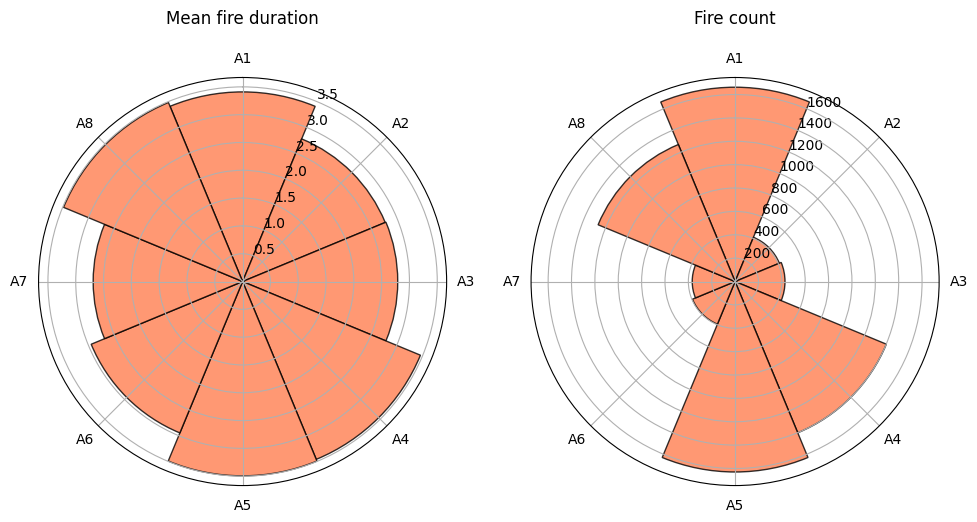

In [4]:
n_cols = 2
n_rows = 1

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 5 * n_rows),
    squeeze=False,
    subplot_kw={'projection': 'polar'}  # ← Makes all subplots polar!
)

titles = {"mean": "Mean fire duration", "count": "Fire count"}

angles = np.linspace(0, 2 * np.pi, 8, endpoint=False)
width = 2 * np.pi / 8 
for i, kind in enumerate(["mean", "count"]):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col] 

    bars = ax.bar(
        angles,
        aspect_stats[kind],
        width=width,
        bottom=0,
        color="coral",
        edgecolor="black",
        alpha=0.8
    )
   
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(angles)
    ax.set_xticklabels([f"A{i}" for i in range(1, 9)])
   
    ax.set_title(titles[kind], pad=20)

plt.tight_layout()
plt.show()

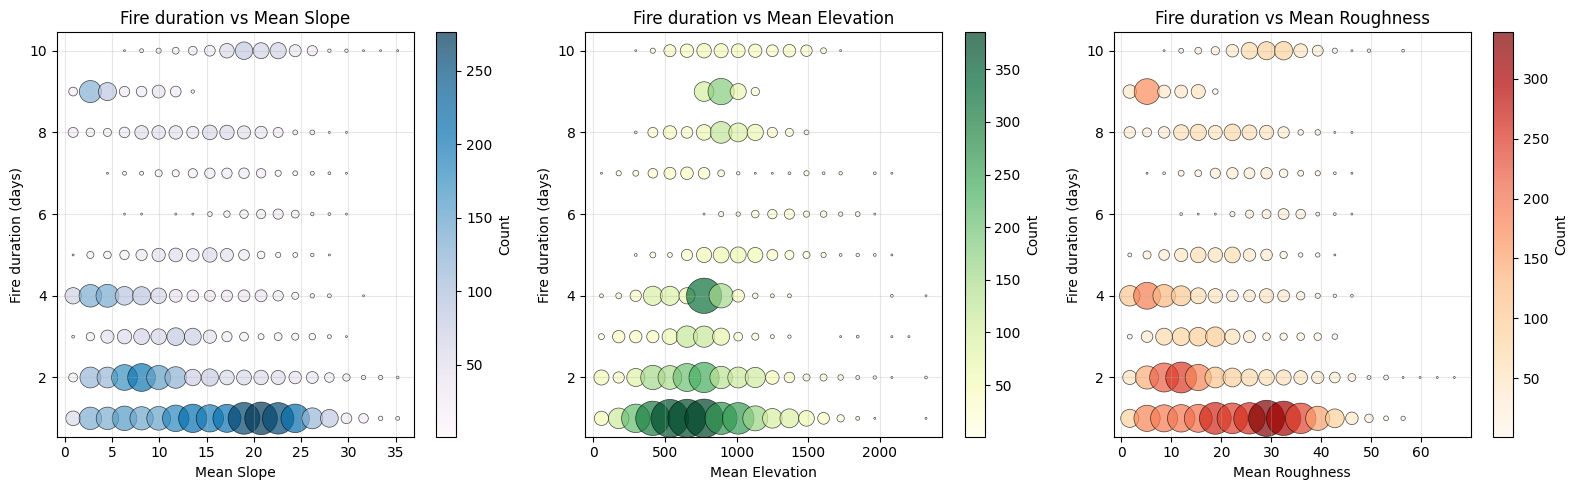

In [5]:
df_filtered = df_fires[df_fires["duration"] >= 0]

terrain_vars = [
    ("slope_mean", "Mean Slope", "PuBu"),
    ("elevation_mean", "Mean Elevation", "YlGn"),
    ("roughness_mean", "Mean Roughness", "OrRd")
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (var, label, color) in zip(axes, terrain_vars):
    # Bin the x variable and count occurrences
    df_temp = df_filtered[[var, "duration"]].dropna()
   
    # Create bins for the terrain variable
    df_temp["var_binned"] = pd.cut(df_temp[var], bins=20, labels=False)
    bin_edges = pd.cut(df_temp[var], bins=20, retbins=True)[1]
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
   
    # Group and count
    grouped = df_temp.groupby(["var_binned", "duration"]).size().reset_index(name="count")
    grouped["var_center"] = grouped["var_binned"].map(lambda i: bin_centers[int(i)] if pd.notna(i) else np.nan)
   
    # Plot bubbles
    scatter = ax.scatter(
        grouped["var_center"],
        grouped["duration"],
        s=grouped["count"] * 2,  # Scale factor for visibility
        c=grouped["count"],
        cmap=color,
        alpha=0.7,
        edgecolors="black",
        linewidths=0.5
    )
   
    ax.set_xlabel(label)
    ax.set_ylabel("Fire duration (days)")
    ax.set_title(f"Fire duration vs {label}")
    ax.grid(alpha=0.3)
   
    cb = plt.colorbar(scatter, ax=ax)
    cb.set_label("Count")

plt.tight_layout()
plt.show()

## 4. Els incendis són més recurrents en zones poc poblades o poc comunicades? 
Veurem els incendis en relació amb la densitat de població (popdens_20<....>), la comunicació del terreny (dist_to<...>) i n’estudiarem la freqüència. . Així veurem si la durada dels incendis  té relació amb com d’urbanitzat està un terreny. Pel que fa a la densitat de població, com que només tenim 2 anys, farem mitjanes ponderades assumint un canvi lineal.

In [6]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import label
import seaborn as sns

# ============================================================
# STEP 1: Select 2022 data
# ============================================================
ds_2022 = ds.sel(time=slice("2022-01-01", "2022-12-31"))

# ============================================================
# STEP 2: Extrapolate Population Density to 2022
# ============================================================

# Available years
pop_years = list(range(2008, 2021))  # 2008-2020

# Load all population density layers
pop_data = {}
for year in pop_years:
    pop_data[year] = ds_2022[f"popdens_{year}"].values 
    
# Stack into 3D array: (year, y, x)
pop_stack = np.stack([pop_data[y] for y in pop_years], axis=0)

# Perform pixel-wise linear regression to extrapolate
ny, nx = pop_stack.shape[1], pop_stack.shape[2]
years_array = np.array(pop_years)
target_year = 2022

# Vectorized approach for speed
# Reshape to (n_years, n_pixels)
pop_flat = pop_stack.reshape(len(pop_years), -1)

# Calculate regression for all pixels at once
# Using the formula: slope = Σ((x-x̄)(y-ȳ)) / Σ((x-x̄)²)
x = years_array
x_mean = x.mean()
x_centered = x - x_mean

# For each pixel
y_mean = np.nanmean(pop_flat, axis=0)
y_centered = pop_flat - y_mean

numerator = np.nansum(x_centered[:, np.newaxis] * y_centered, axis=0)
denominator = np.sum(x_centered ** 2)

slopes = numerator / denominator
intercepts = y_mean - slopes * x_mean

# Extrapolate to 2022
popdens_2022_flat = slopes * target_year + intercepts
popdens_2022 = popdens_2022_flat.reshape(ny, nx)

# Ensure no negative population densities
popdens_2022 = np.maximum(popdens_2022, 0)

# ============================================================
# STEP 3: Load infrastructure distance variables
# ============================================================

infrastructure_vars = {
    "dist_roads_mean": ds_2022["dist_to_roads_mean"].values,
    "dist_roads_std": ds_2022["dist_to_roads_stdev"].values,
    "dist_water_mean": ds_2022["dist_to_waterways_mean"].values,
    "dist_water_std": ds_2022["dist_to_waterways_stdev"].values,
    "dist_rail_mean": ds_2022["dist_to_railways_mean"].values,
    "dist_rail_std": ds_2022["dist_to_railways_stdev"].values,
}

# ============================================================
# STEP 4: Process fire events (optimized)
# ============================================================
fire = ds_2022["is_fire"]
fire_vals = fire.values
fire_vals = np.nan_to_num(fire_vals, nan=0)

# Find fire starts
fire_start = (fire_vals == 1) & (np.roll(fire_vals, 1, axis=0) == 0)
fire_start[0, :, :] = fire_vals[0, :, :] == 1  # Handle first timestep

# Find pixels with fires
has_fire = fire_vals.any(axis=0)
fire_pixels = np.argwhere(has_fire)

# Extract fire events with all attributes
records = []

for iy, ix in fire_pixels:
    ts = fire_vals[:, iy, ix]
   
    # Label connected fire segments
    labels, n_fires = label(ts)
   
    for fire_id in range(1, n_fires + 1):
        fire_indices = np.where(labels == fire_id)[0]
        duration = len(fire_indices)
       
        records.append({
            "y": iy,
            "x": ix,
            "duration": duration,
            "popdens_2022": popdens_2022[iy, ix],
            "dist_roads_mean": infrastructure_vars["dist_roads_mean"][iy, ix],
            "dist_roads_std": infrastructure_vars["dist_roads_std"][iy, ix],
            "dist_water_mean": infrastructure_vars["dist_water_mean"][iy, ix],
            "dist_water_std": infrastructure_vars["dist_water_std"][iy, ix],
            "dist_rail_mean": infrastructure_vars["dist_rail_mean"][iy, ix],
            "dist_rail_std": infrastructure_vars["dist_rail_std"][iy, ix],
        })

df_fires = pd.DataFrame(records)

# Filter valid data
df_fires = df_fires[df_fires["duration"] > 0]
df_fires = df_fires.dropna()

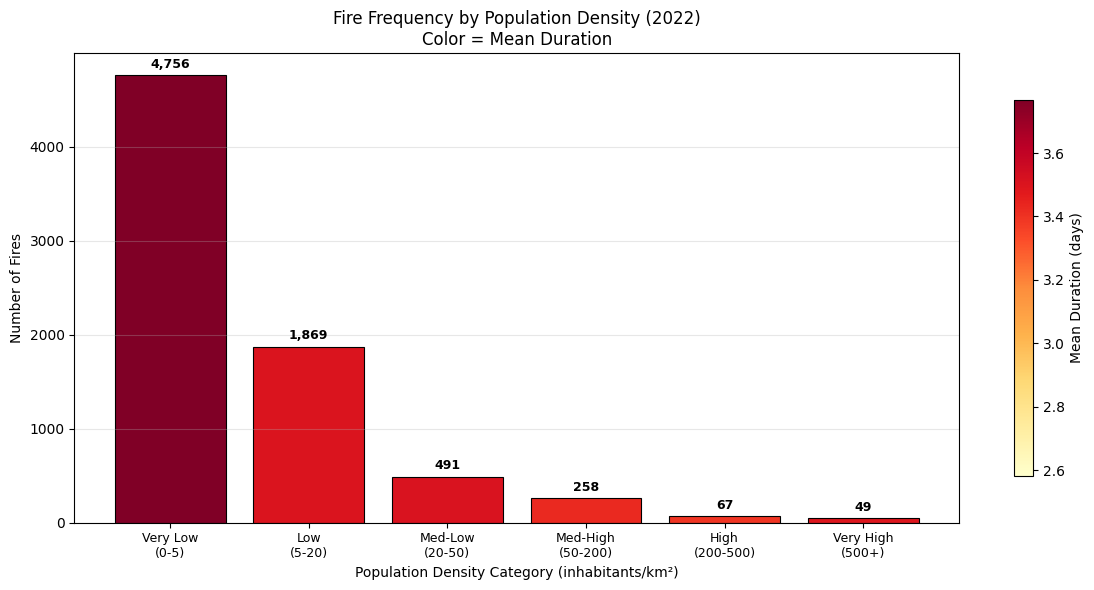


Fire count by population density bin:
           pop_bin  fire_count  mean_duration
   Very Low\n(0-5)        4756       3.767031
       Low\n(5-20)        1869       2.939005
  Med-Low\n(20-50)         491       2.945010
Med-High\n(50-200)         258       2.678295
   High\n(200-500)          67       2.582090
 Very High\n(500+)          49       2.897959


In [7]:
# ============================================================
# VISUALIZATION 2: Binned Bar Chart (FIXED)
# ============================================================
plt.close('all')

# Option A: Custom bins based on your data distribution (RECOMMENDED for skewed data)
# Since mean=20 but max=3700, use log-like spacing
custom_bins = [0, 5, 20, 50, 200, 500, df_fires["popdens_2022"].max() + 1]
custom_labels = ["Very Low\n(0-5)", "Low\n(5-20)", "Med-Low\n(20-50)",
                 "Med-High\n(50-200)", "High\n(200-500)", "Very High\n(500+)"]

df_fires["pop_bin"] = pd.cut(
    df_fires["popdens_2022"],
    bins=custom_bins,
    labels=custom_labels,
    include_lowest=True
)

# Aggregate by bin
pop_stats = df_fires.groupby("pop_bin", observed=True).agg(
    fire_count=("duration", "count"),
    mean_duration=("duration", "mean")
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    range(len(pop_stats)),
    pop_stats["fire_count"],
    color=plt.cm.YlOrRd(pop_stats["mean_duration"] / pop_stats["mean_duration"].max()),
    edgecolor="black",
    linewidth=0.8
)

ax.set_xticks(range(len(pop_stats)))
ax.set_xticklabels(pop_stats["pop_bin"], fontsize=9)
ax.set_xlabel("Population Density Category (inhabitants/km²)")
ax.set_ylabel("Number of Fires")
ax.set_title("Fire Frequency by Population Density (2022)\nColor = Mean Duration", fontsize=12)
ax.grid(axis="y", alpha=0.3)

# Colorbar
sm = plt.cm.ScalarMappable(
    cmap="YlOrRd",
    norm=plt.Normalize(
        vmin=pop_stats["mean_duration"].min(),
        vmax=pop_stats["mean_duration"].max()
    )
)
cbar = plt.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label("Mean Duration (days)")

# Add count labels on bars
for bar, count in zip(bars, pop_stats["fire_count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(pop_stats["fire_count"]) * 0.01,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# Print the distribution
print("\nFire count by population density bin:")
print(pop_stats[["pop_bin", "fire_count", "mean_duration"]].to_string(index=False))

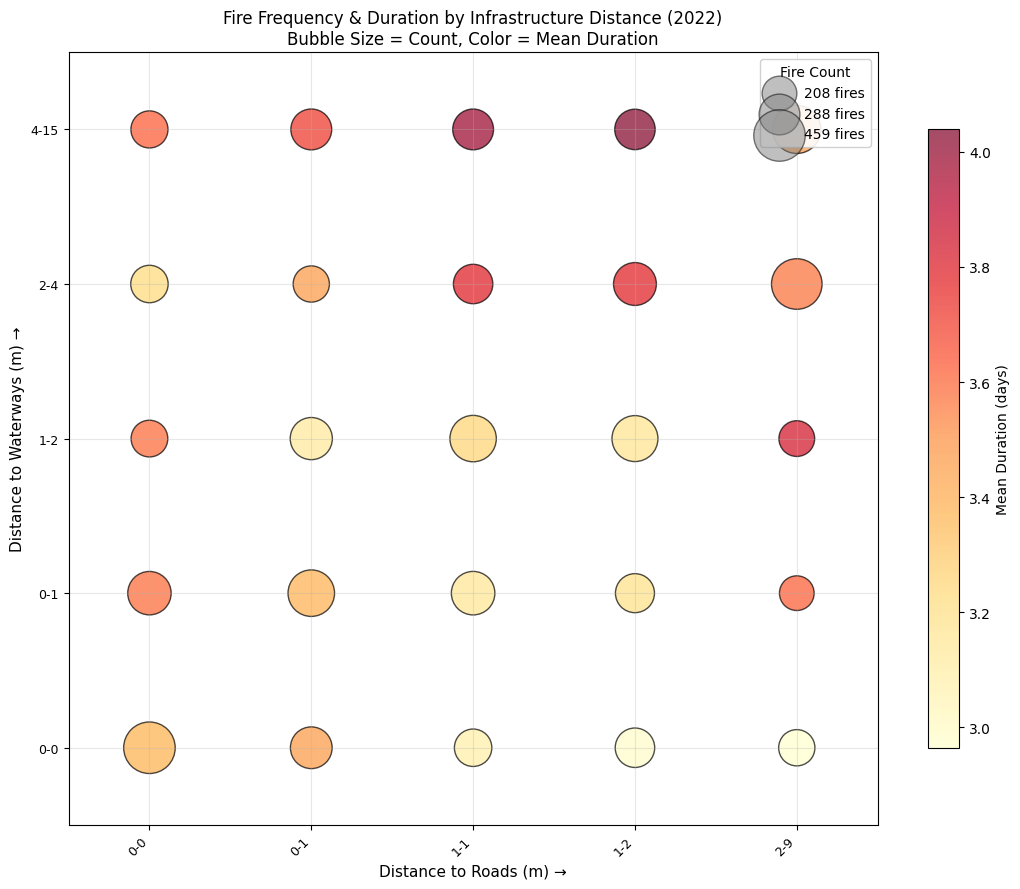

In [8]:
# ============================================================
# VISUALIZATION 3: Bubble Matrix (FIXED with range labels)
# ============================================================
plt.close('all')

n_bins = 5

# Create bins and capture the actual ranges
df_fires["roads_bin"], roads_edges = pd.qcut(
    df_fires["dist_roads_mean"],
    q=n_bins,
    labels=False,
    retbins=True,
    duplicates="drop"
)

df_fires["water_bin"], water_edges = pd.qcut(
    df_fires["dist_water_mean"],
    q=n_bins,
    labels=False,
    retbins=True,
    duplicates="drop"
)

# Create labels with actual ranges
roads_labels = [f"{roads_edges[i]:.0f}-{roads_edges[i+1]:.0f}"
                for i in range(len(roads_edges)-1)]
water_labels = [f"{water_edges[i]:.0f}-{water_edges[i+1]:.0f}"
                for i in range(len(water_edges)-1)]

# Aggregate
bubble_data = df_fires.groupby(["roads_bin", "water_bin"], observed=True).agg(
    count=("duration", "count"),
    mean_duration=("duration", "mean")
).reset_index()

fig, ax = plt.subplots(figsize=(11, 9))

scatter = ax.scatter(
    bubble_data["roads_bin"],
    bubble_data["water_bin"],
    s=bubble_data["count"] * 3,
    c=bubble_data["mean_duration"],
    cmap="YlOrRd",
    alpha=0.7,
    edgecolors="black",
    linewidths=1
)

# Set ticks with actual range labels
ax.set_xticks(range(len(roads_labels)))
ax.set_xticklabels(roads_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(water_labels)))
ax.set_yticklabels(water_labels, fontsize=9)

ax.set_xlabel("Distance to Roads (m) →", fontsize=11)
ax.set_ylabel("Distance to Waterways (m) →", fontsize=11)
ax.set_title("Fire Frequency & Duration by Infrastructure Distance (2022)\n"
             "Bubble Size = Count, Color = Mean Duration", fontsize=12)

ax.set_xlim(-0.5, len(roads_labels) - 0.5)
ax.set_ylim(-0.5, len(water_labels) - 0.5)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label("Mean Duration (days)")

# Legend for bubble size
sizes_for_legend = [
    bubble_data["count"].min(),
    bubble_data["count"].median(),
    bubble_data["count"].max()
]
for size in sizes_for_legend:
    ax.scatter([], [], s=size*3, c="gray", alpha=0.5,
               edgecolors="black", label=f"{int(size)} fires")
ax.legend(title="Fire Count", loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.show()

## 5. A Catalunya, la quantitat de bombers és proporcional a la quantitat d'incendis? 
Veurem els detalls urbans: ens centrarem en Catalunya i la quantitat de parcs de bombers, relacionant-ne la quantitat amb la freqüència i durada dels incendis.

Ho fem combinant el dataset que tenim amb les dades de [la quantitat de bombers i bombers voluntaris l'any 2022 a Catalunya](https://analisi.transparenciacatalunya.cat/Seguretat/Parcs-de-bombers-per-regi-d-emerg-ncies/8ymu-ma9b/about_data)

In [12]:
ds_t0 = ds.isel(time=0)
mask_ac9 = ds_t0["AutonomousCommunities"] == 9
painted = xr.where(mask_ac9, 1, 0)
X, Y = xr.broadcast(ds_t0["x"], ds_t0["y"])

region = xr.full_like(X, np.nan, dtype=np.float32)

region = xr.where(mask_ac9  & (X <= 3550000) & (Y<= 2060000), 1, region)
region = xr.where(mask_ac9  & (((X <= ((10*Y + 4250000)/7)) & (Y> 2060000)  & (Y <= 2130000)) | ((X < 3650000) & (Y> 2130000))), 2, region)
region = xr.where(mask_ac9  & ( (X <= 3650000) & (((X > ((10*Y + 4250000)/7)) & (Y> 2060000) & (Y <= 2130000)) | ((X > 3550000) & (Y<= 2060000))) ), 4, region)
region = xr.where(mask_ac9  & (Y <= 2120000) & (X <= (32260000 - 3*Y) / 7) & (X > 3650000), 5, region)
region = xr.where(mask_ac9  & (Y <= 2120000) & (X > (32260000 - 3*Y) / 7) & (X > 3650000), 6, region)
region = xr.where(mask_ac9  & (X > 3650000) & (X <= 3700000) & (Y >2120000), 7, region)
region = xr.where(mask_ac9  & (X > 3700000) & (Y >2120000), 8, region)
region = xr.where(mask_ac9  & (X <= (11 * Y - 13220000) / 3), 3, region)

ds_t0["region"] = region

region_labels = {
    1: "Regió d'Emergències Terres de l'Ebre",
    2: "Regió d'Emergències Lleida",
    3: "Regió d'Emergències Vall d'Aran",
    4: "Regió d'Emergències Tarragona",
    5: "Regió d'Emergències Metropolitana Sud",
    6: "Regió d'Emergències Metropolitana Nord",
    7: "Regió d'Emergències Centre",
    8: "Regió d'Emergències Girona",
}

region_colors = {
    1: "#1fd355",
    2: "#278ddb",
    3: "#1200a8",
    4: "#0f8e1e",
    5: "#8512a8",
    6: "#e246c8",
    7: "#cdd31f",
    8: "#d3911f",
}

In [13]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import label

# ============================================================
# STEP 1: Select 2022 data and load to memory
# ============================================================
ds_2022 = ds.sel(time=slice("2022-01-01", "2022-12-31"))

# Fire data
fire_vals = ds_2022["is_fire"].values
fire_vals = np.nan_to_num(fire_vals, nan=0)

# Region data (static - from ds_t0 which you already created)
region_vals = ds_t0["region"]

# ============================================================
# STEP 2: Process fire events by region (optimized)
# ============================================================
# Find pixels with fires
has_fire = fire_vals.any(axis=0)
fire_pixels = np.argwhere(has_fire)

# Extract fire events
records = []

for iy, ix in fire_pixels:
    ts = fire_vals[:, iy, ix]
    pixel_region = region_vals[iy, ix]
   
    # Skip if region is NaN (outside the study area)
    if np.isnan(pixel_region):
        continue
   
    # Label connected fire segments
    labels, n_fires = label(ts)
   
    for fire_id in range(1, n_fires + 1):
        fire_indices = np.where(labels == fire_id)[0]
        duration = len(fire_indices)
       
        records.append({
            "region": int(pixel_region),
            "duration": duration,
        })

df_fires = pd.DataFrame(records)
df_fires = df_fires[df_fires["duration"] > 0]

# ============================================================
# STEP 3: Aggregate by region
# ============================================================
region_stats = None
region_stats = df_fires.groupby("region").agg(
    fire_count=("duration", "count"),
    mean_duration=("duration", "mean"),
    median_duration=("duration", "median"),
    total_fire_days=("duration", "sum")
).reset_index()

region_stats["region_name"] = region_stats["region"].map(region_labels)
region_stats["color"] = region_stats["region"].map(region_colors)


# ============================================================
# STEP 4: Load firefighter data from CSV
# ============================================================
# CSV has columns: region_name, ff_normal, ff_volunteer
ff_data = pd.read_csv("bombers.csv")

# Merge with region stats
region_stats = region_stats.merge(ff_data, on="region", how="outer")


# Calculate total firefighters
region_stats["ff_total"] = region_stats["Funcionaris"] + region_stats["Voluntaris"]

# Calculate efficiency metrics
region_stats["ff_per_fire"] = region_stats["ff_total"] / region_stats["fire_count"]
region_stats["fires_per_ff"] = region_stats["fire_count"] / region_stats["ff_total"]

region_stats = region_stats.fillna(0)

region_stats.loc[region_stats.region == 5, 'region_name'] =  "Regió d'Emergències Metropolitana Sud"
region_stats.loc[region_stats.region == 7, 'region_name'] =  "Regió d'Emergències Centre"


C:\Users\esthe\AppData\Local\Temp\ipykernel_1892\1505011031.py:82: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  fire_circle = plt.Circle(
C:\Users\esthe\AppData\Local\Temp\ipykernel_1892\1505011031.py:93: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ff_circle = plt.Circle(


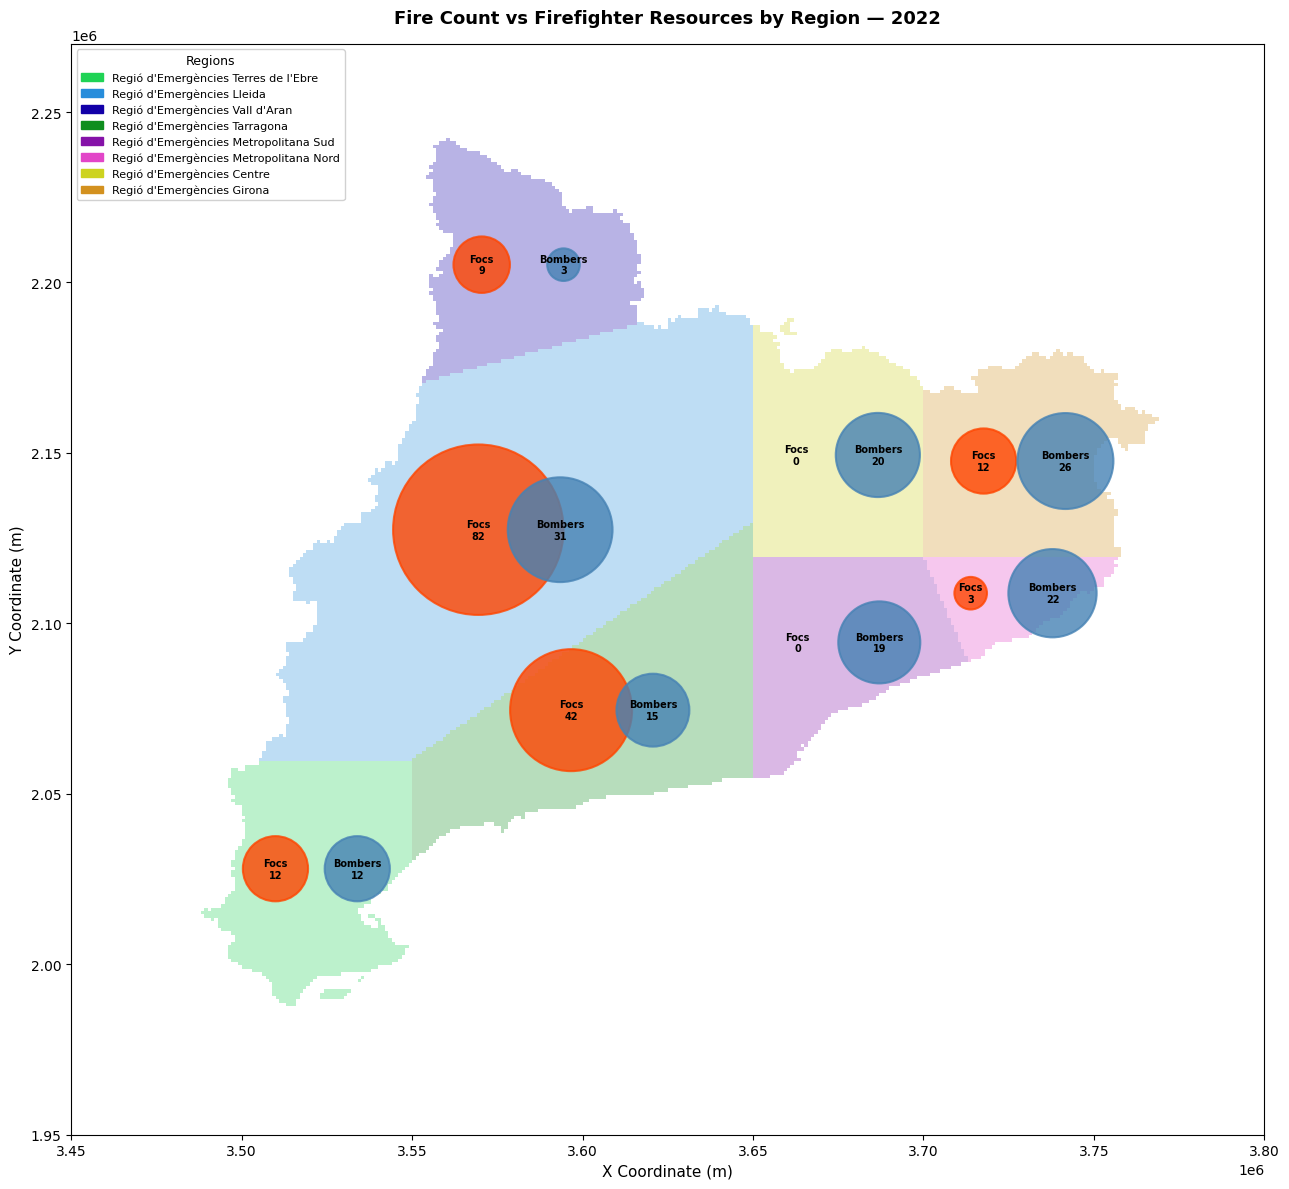

In [14]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

# ============================================================
# STEP 1: Calculate centroids for each region
# ============================================================

# Get x and y coordinates from the dataset
x_coords = ds_t0["x"].values
y_coords = ds_t0["y"].values

# Calculate centroid for each region
centroids = {}

for region_id in region_labels.keys():
    mask = region_vals == region_id
   
    if mask.any():
        # Get indices where this region exists
        y_indices, x_indices = np.where(mask)
       
        # Convert to actual coordinates
        region_x_coords = x_coords[x_indices]
        region_y_coords = y_coords[y_indices]
       
        # Calculate centroid
        centroid_x = region_x_coords.mean()
        centroid_y = region_y_coords.mean()
       
        centroids[region_id] = (centroid_x, centroid_y)
# ============================================================
# STEP 2: Create the combined map visualization
# ============================================================
plt.close('all')

# Base map setup
region_colors_list = [region_colors[i] for i in sorted(region_colors.keys())]
cmap = mcolors.ListedColormap(region_colors_list)
bounds = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(14, 12))

# Plot the region map as background (low alpha)
x_coords = ds_t0["x"].values
y_coords = ds_t0["y"].values

im = ax.imshow(
    region_vals,
    extent=[x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()],
    origin="upper",
    cmap=cmap,
    norm=norm,
    alpha=0.3
)

# ============================================================
# Add proportional circles at each centroid
# ============================================================

max_val = max(region_stats["fire_count"].max(), region_stats["ff_total"].max())
max_radius = 25000
offset = 12000

for region_id, (cx, cy) in centroids.items():
    stats = region_stats[region_stats["region"] == region_id]
   
    if len(stats) == 0:
        continue
   
    row = stats.iloc[0]
   
    fire_count = row["fire_count"]
    ff_total = row["ff_total"]
   
    fire_radius = np.sqrt(fire_count / max_val) * max_radius
    ff_radius = np.sqrt(ff_total / max_val) * max_radius
   
    # Fire circle (left)
    fire_circle = plt.Circle(
        (cx - offset, cy),
        fire_radius,
        color="orangered",
        alpha=0.8,
        edgecolor="darkred",
        linewidth=1.5
    )
    ax.add_patch(fire_circle)
   
    # Firefighter circle (right)
    ff_circle = plt.Circle(
        (cx + offset, cy),
        ff_radius,
        color="steelblue",
        alpha=0.8,
        edgecolor="darkblue",
        linewidth=1.5
    )
    ax.add_patch(ff_circle)
   
    # Label on fire circle
    ax.text(
        cx - offset, cy,
        f"Focs\n{int(fire_count)}",
        ha="center", va="center",
        fontsize=7, fontweight="bold",
        color="black"
    )
   
    # Label on firefighter circle
    ax.text(
        cx + offset, cy,
        f"Bombers\n{int(ff_total)}",
        ha="center", va="center",
        fontsize=7, fontweight="bold",
        color="black"
    )

# ============================================================
# Formatting
# ============================================================

xmin, xmax = 3450000, 3800000
ymin, ymax = 1950000, 2270000
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect('equal')

ax.set_xlabel("X Coordinate (m)", fontsize=11)
ax.set_ylabel("Y Coordinate (m)", fontsize=11)
ax.set_title("Fire Count vs Firefighter Resources by Region — 2022",
             fontsize=13, fontweight="bold", pad=15)

legend_patches = [
    mpatches.Patch(color=region_colors[region_id], label=region_labels[region_id])
    for region_id in sorted(region_labels.keys())
]
ax.legend(handles=legend_patches, loc="upper left", title="Regions",
          fontsize=8, title_fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

# Conclusions

* Els dies abans d'un incendi:
  * El fullatge per metre quadrat incrementa.
  * El percentatge d'aigua al sol incrementa, però només a les capes superiors.
  * La temperatura incrementa i la humitat a l'aire baixa notablement.
  * La direcció del vent mostra canvis sobtats.
* Trobem més incendis quan el terreny està inclinat cap al Nord-Oest i cap al Sud-Est.
* Trobem més focs en terrenys inclinats.
* Els incendis són més comuns i duren més allà on la densitat de població és baixa.
* La distància a fonts d'aigua té més impacte a la distància a carreteres en la durada dels incendis.
* Les regions amb més incendis tenen més bombers, però les regions amb més bombers no tenen més incendis.